# Audio Quality File Exploration
Visualizes the audio feature extraction

In [1]:
# Check python version for compatibility with librosa, 3.12.8 is OK in 2025
!python3 --version

Python 3.12.7


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import IPython.display as ipd
import soundfile as sf
import os
import sys
from pathlib import Path

In [10]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent))
print(sys.path)

['/Users/KRubio/.pyenv/versions/3.12.7/lib/python312.zip', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12/lib-dynload', '', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification']


In [3]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent))
print(sys.path)

['/Users/KRubio/.pyenv/versions/3.12.7/lib/python312.zip', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12/lib-dynload', '', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification']


In [ ]:
from utils.time_domain_utils import (
  plot_waveform,
  plot_waveform_with_line,
  amplitude_envelope,
)
from utils.frequency_domain_utils import (
  plot_spectrogram,
  short_time_fourier_transform,
  plot_spectral_centroid,
  plot_mfccs,
  reduce_stationary_noise,
)

In [12]:
sr = 16000
filename1 = 'chips.wav'
filepath1 = f'../data/audio/{filename1}'
# Librosa.load automatically resamples at sr=22050
file1, _ = librosa.load(filepath1, sr=sr)

filename2 = 'chips_skype.wav'
filepath2 = f'../data/audio/{filename2}'
file2, _ = librosa.load(filepath2, sr=sr)


In [9]:
ipd.Audio(file1, rate=sr)

In [ ]:
ipd.Audio(file2, rate=sr)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Child speaking'}, xlabel='Time (sec)', ylabel='Amplitude'>)

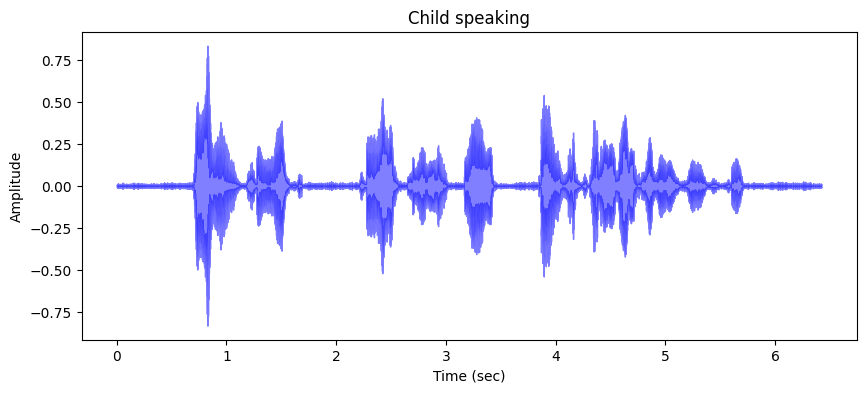

In [11]:
plot_waveform(file1, 'Child speaking', sr)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Child speaking with mic banging sounds'}, xlabel='Time (sec)', ylabel='Amplitude'>)

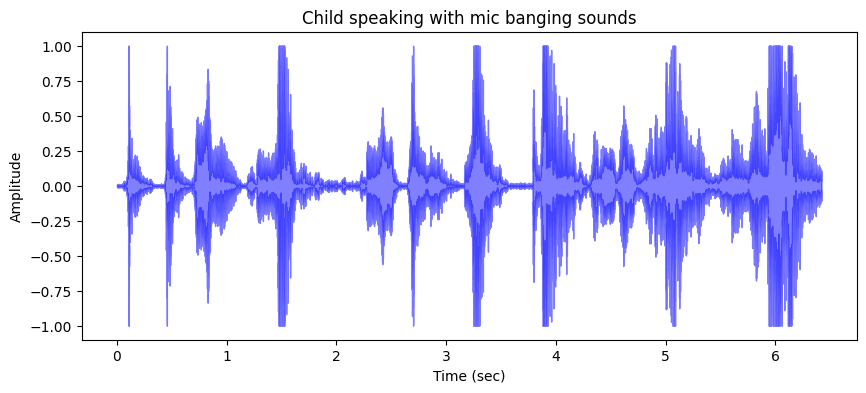

In [12]:
plot_waveform(file2, 'Child speaking with mic banging sounds', sr)

In [16]:
FRAME_LENGTH = 1024
HOP_LENGTH = FRAME_LENGTH//4

## Root Mean Square Energy

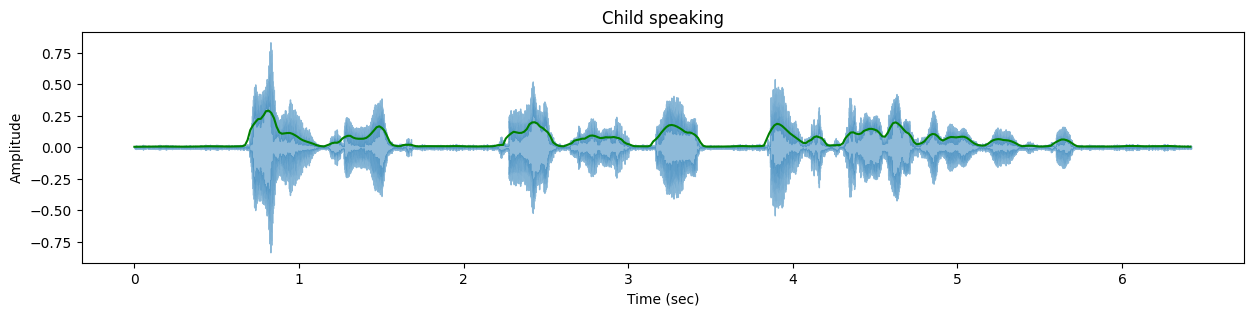

In [17]:
# Calculate rms as array using librosa.feature.rms and check the size of the resulting array
rms1 = librosa.feature.rms(y=file1, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
plot_waveform_with_line(file1, "Child speaking", HOP_LENGTH, sr, rms1, "g")

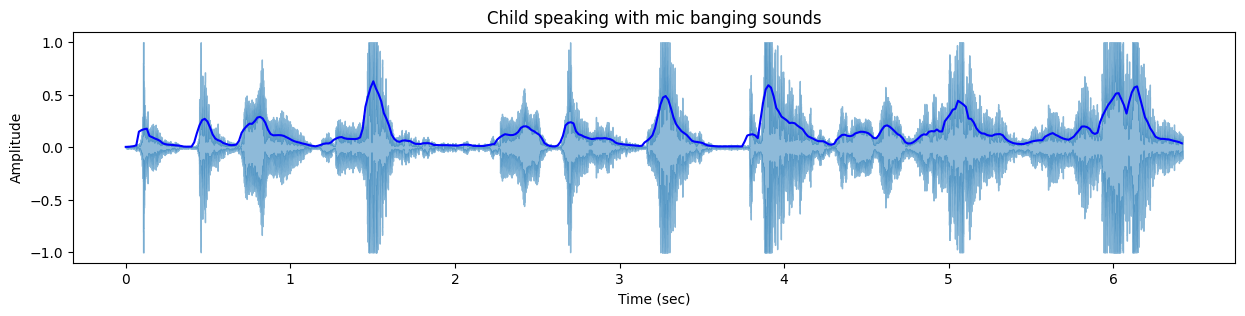

In [19]:
# Calculate rms as array using librosa.feature.rms and check the size of the resulting array
rms2 = librosa.feature.rms(y=file2, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
plot_waveform_with_line(file2, "Child speaking with mic banging sounds", HOP_LENGTH, sr, rms2, "b")

## Zero Crossing Rate

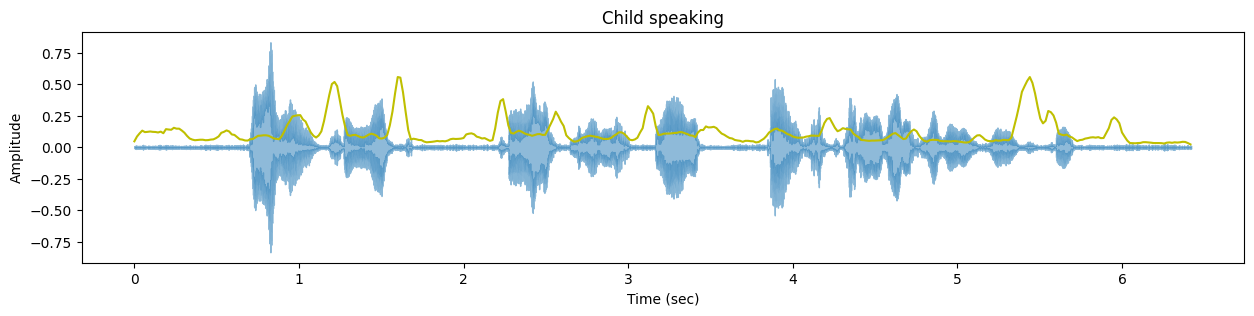

In [18]:
# Calculate ZCR using librosa.feature.zero_crossing_rate
zcr1 = librosa.feature.zero_crossing_rate(y=file1, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
plot_waveform_with_line(file1, "Child speaking", HOP_LENGTH, sr, zcr1, "y")

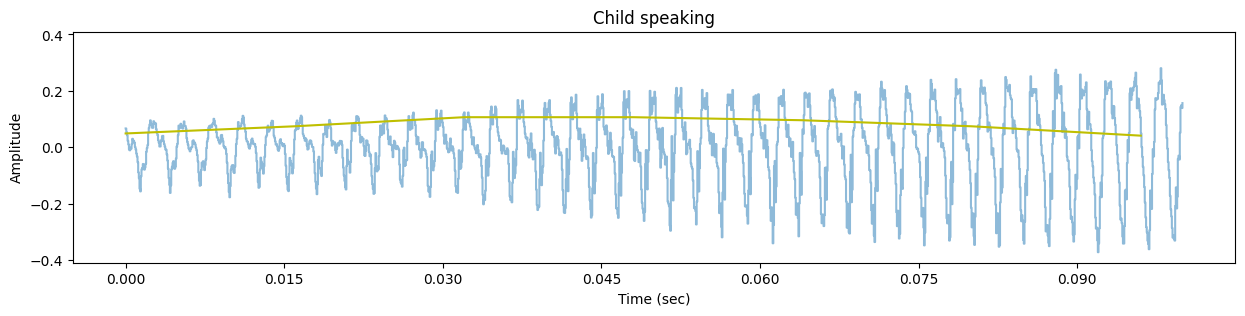

In [ ]:
# Zoom in on 1.4-1.5 seconds of the file above and look at ZCR
start = round(sr*1.4)
end = round(sr*1.5)
subfile = file1[start:end]
zcr_subfile = librosa.feature.zero_crossing_rate(y=subfile, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
plot_waveform_with_line(subfile, "Child speaking", HOP_LENGTH, sr, zcr_subfile, "y")

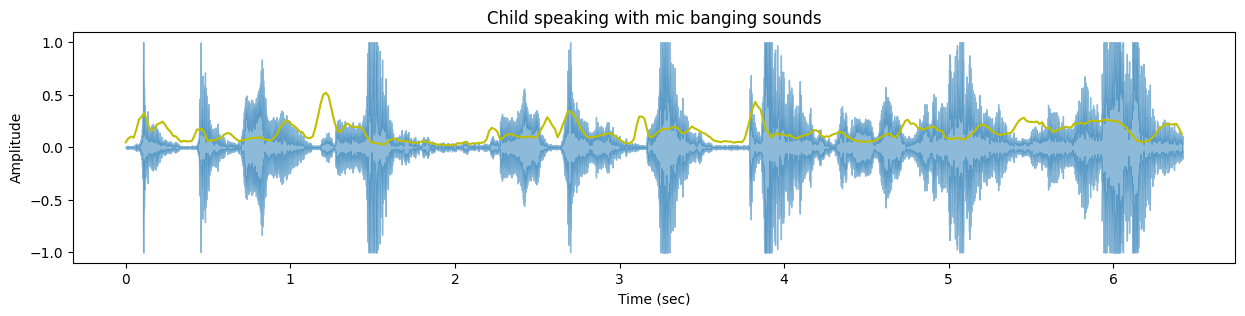

In [20]:
# Calculate ZCR using librosa.feature.zero_crossing_rate
zcr2 = librosa.feature.zero_crossing_rate(y=file2, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
plot_waveform_with_line(file2, "Child speaking with mic banging sounds", HOP_LENGTH, sr, zcr2, "y")

## Fourier Transform and Spectrograms

In [13]:
# Apply short-time fourier transform to change audio from time-domain 
# to frequency-domain
stft1 = short_time_fourier_transform(file1, FRAME_LENGTH, HOP_LENGTH)

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

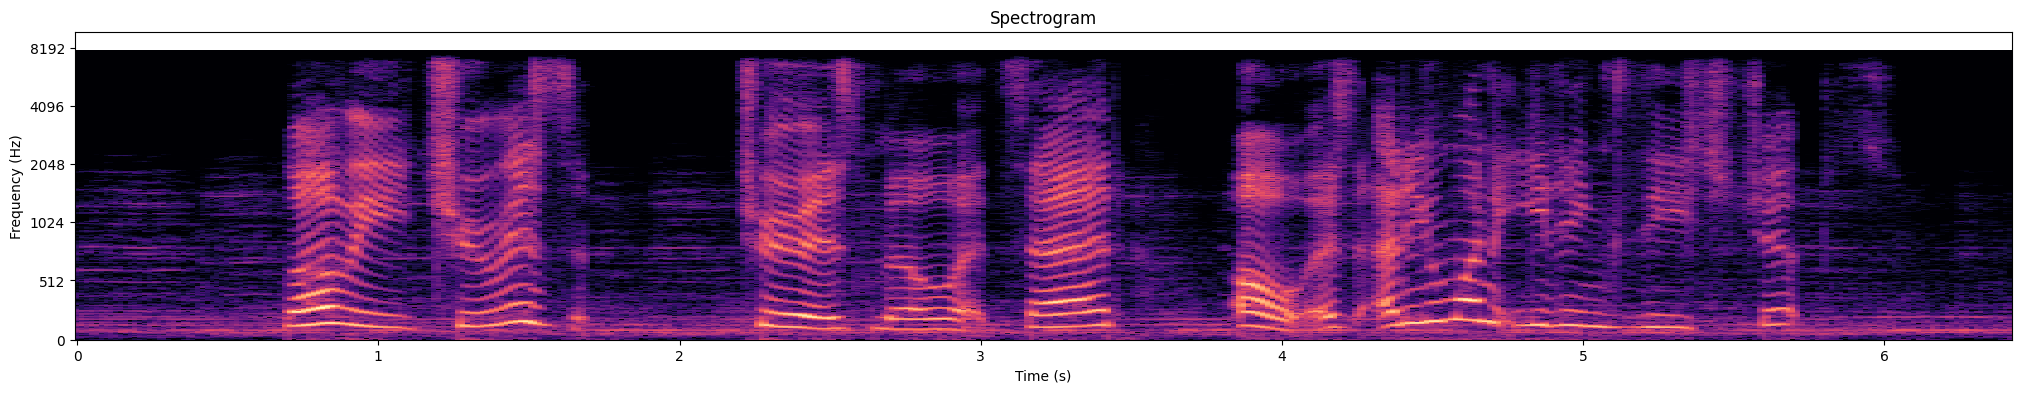

In [14]:
# Plot spectrogram, use the mel scale for frequency
plot_spectrogram(stft1, sr, HOP_LENGTH, "mel", 0, 10000)

In [15]:
# Apply short-time fourier transform to change audio from time-domain 
# to frequency-domain
stft2 = short_time_fourier_transform(file2, FRAME_LENGTH, HOP_LENGTH)

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

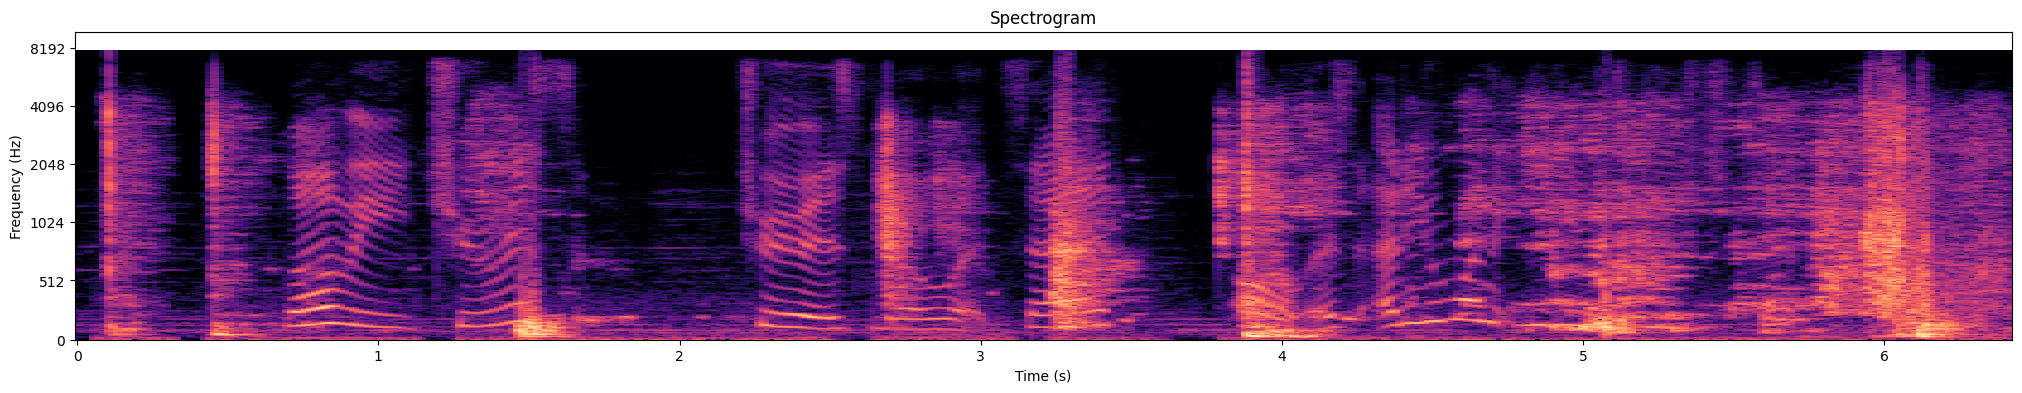

In [16]:
# Plot spectrogram, use the mel scale for frequency
plot_spectrogram(stft2, sr, HOP_LENGTH, "mel", 0, 10000)

## MFCCs

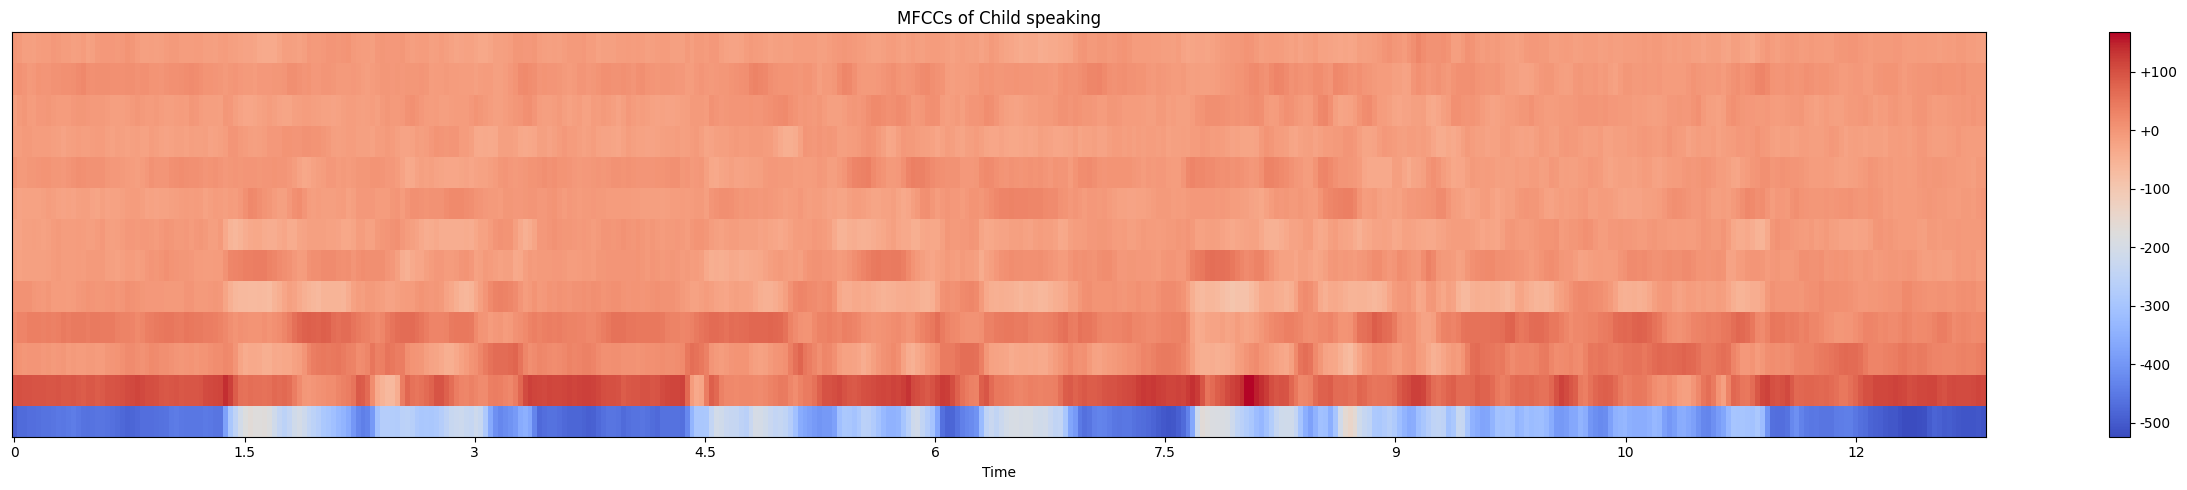

In [24]:
# Extract the first 13 MFCCs
mfccs1 = librosa.feature.mfcc(y=file1, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH, n_mfcc=13)
plot_mfccs(mfccs1, sr, 'MFCCs of Child speaking')

In [ ]:
mfcc_stats = {}
for i in range (mfccs1.shape[0]):
  mfcc_stats[f'mfcc{i+1}_avg'] = np.mean(mfccs1[i])
  mfcc_stats[f'mfcc{i+1}_min'] = np.min(mfccs1[i])
  mfcc_stats[f'mfcc{i+1}_max'] = np.max(mfccs1[i])

print(mfcc_stats['mfcc1_avg'])
print(mfcc_stats['mfcc2_avg'])
print(mfcc_stats['mfcc13_avg'])

-359.9709
74.26018
-12.659695


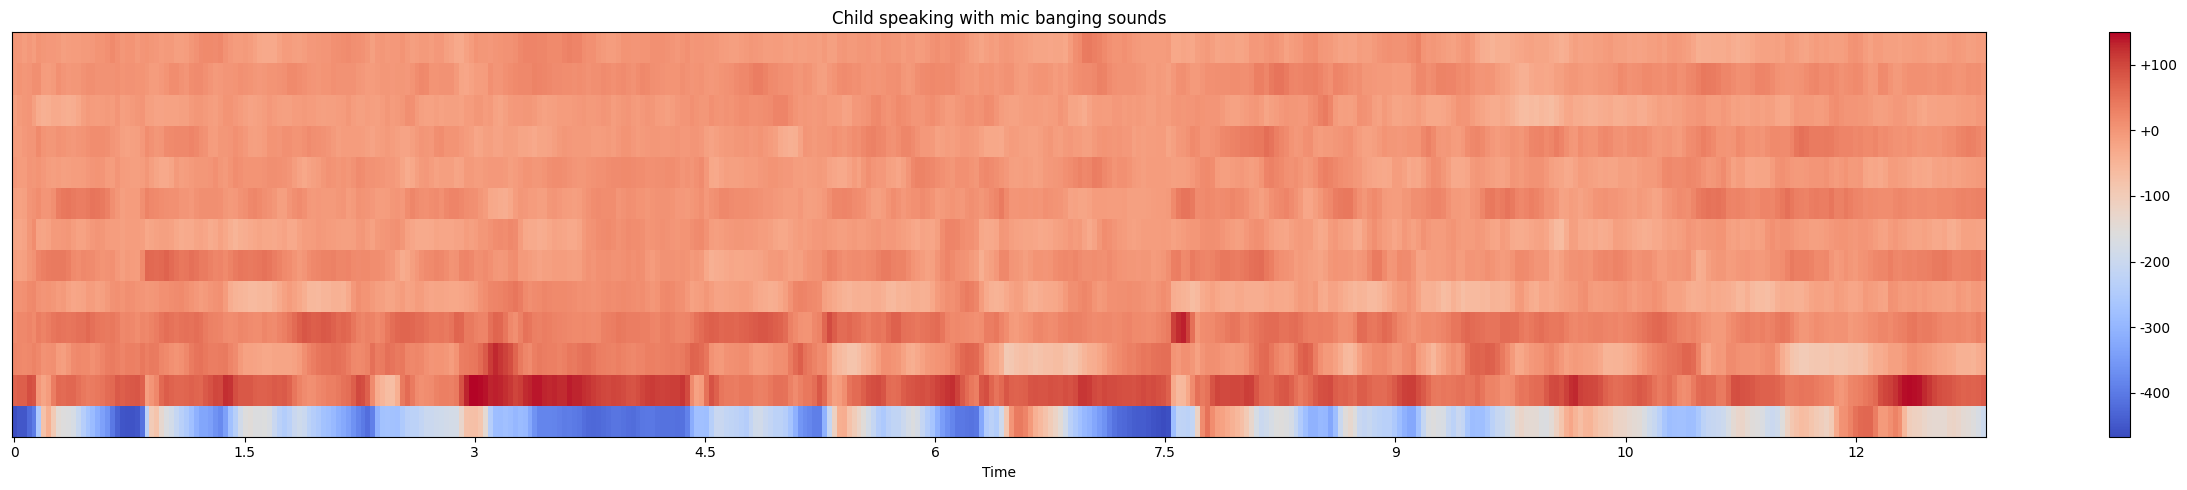

In [22]:
# Extract the first 13 MFCCs
mfccs2 = librosa.feature.mfcc(y=file2, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH, n_mfcc=13)
plot_mfccs(mfccs2, sr, 'Child speaking with mic banging sounds')

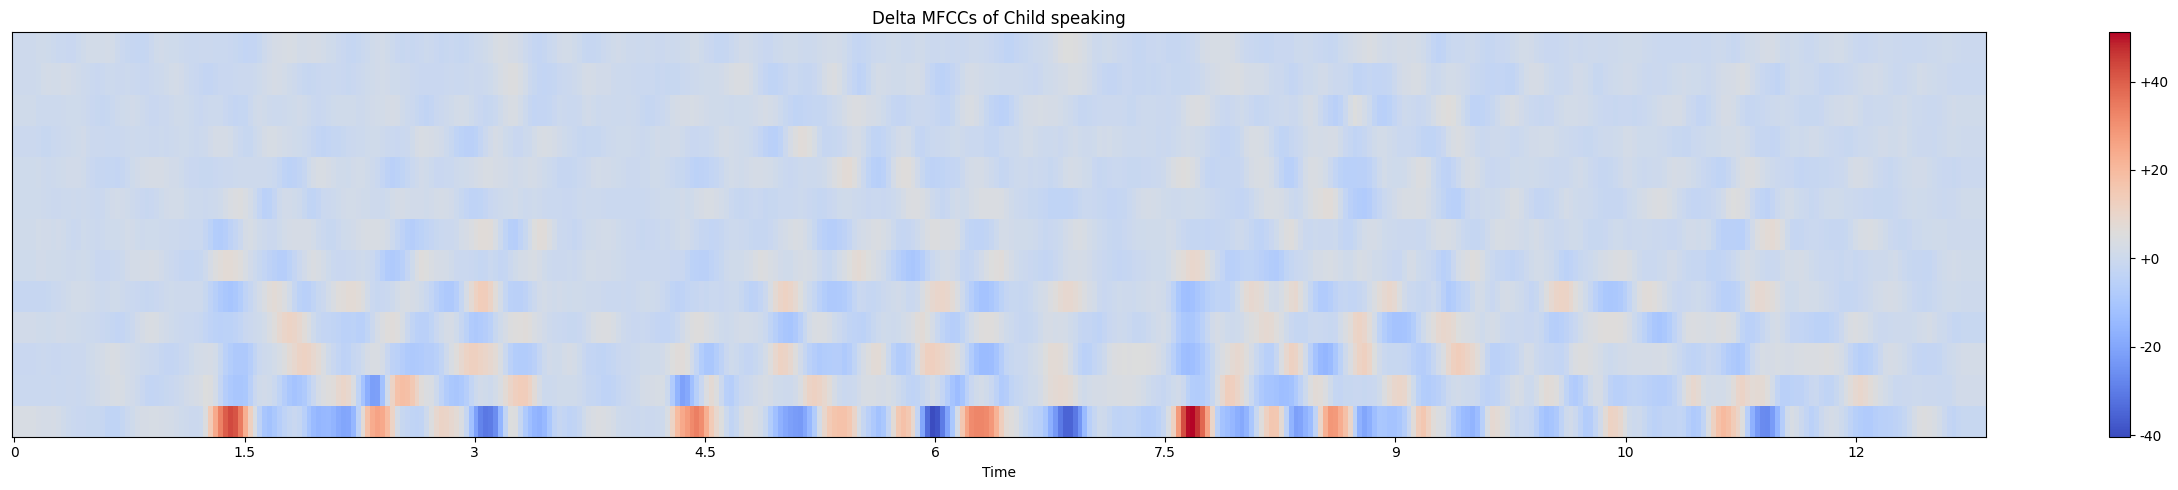

In [25]:
# Computing first MFCCs derivatives (how they change from frame-frame over time)
delta_mfccs1 = librosa.feature.delta(mfccs1)
plot_mfccs(delta_mfccs1, sr, 'Delta MFCCs of Child speaking')

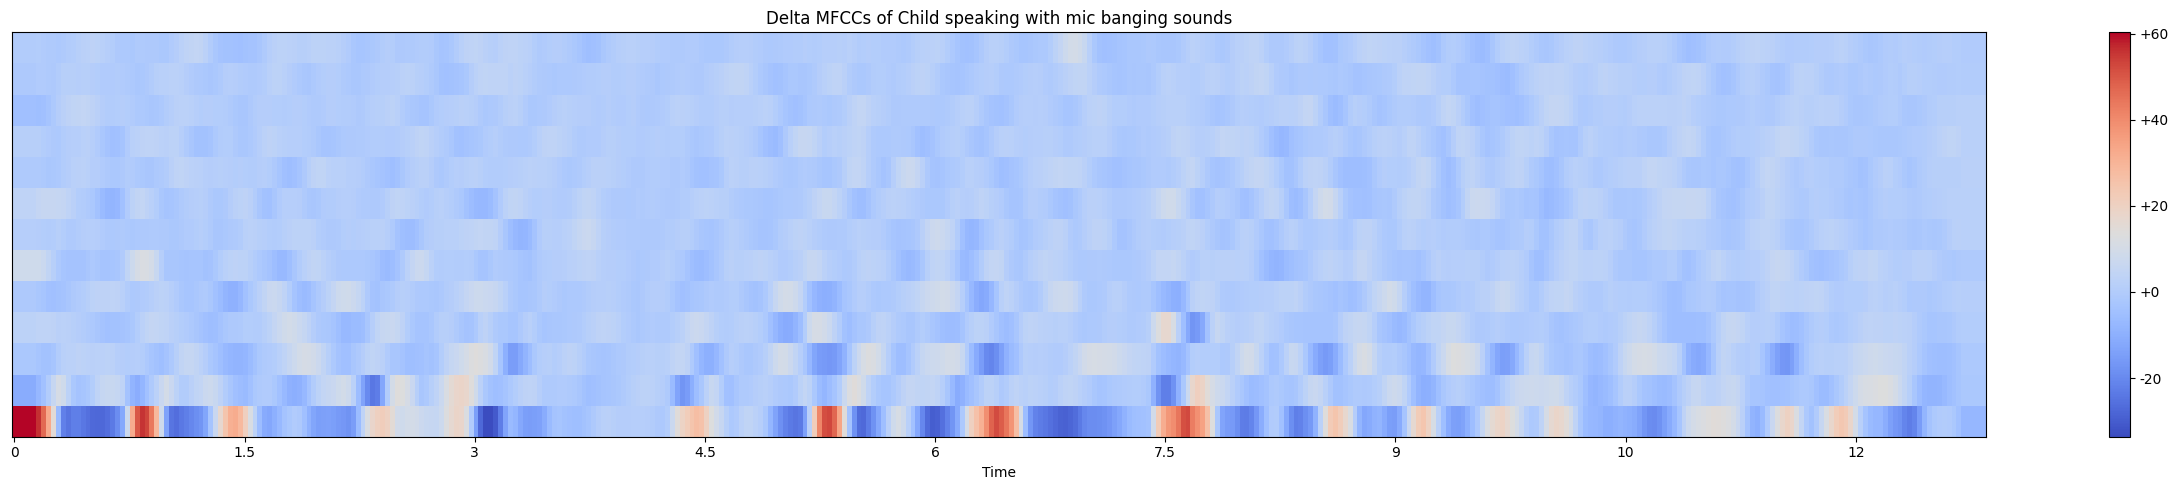

In [26]:
# Computing first MFCCs derivatives (how they change from frame-frame over time)
delta_mfccs2 = librosa.feature.delta(mfccs2)
plot_mfccs(delta_mfccs2, sr, 'Delta MFCCs of Child speaking with mic banging sounds')

## Spectral Centroid and Bandwidth

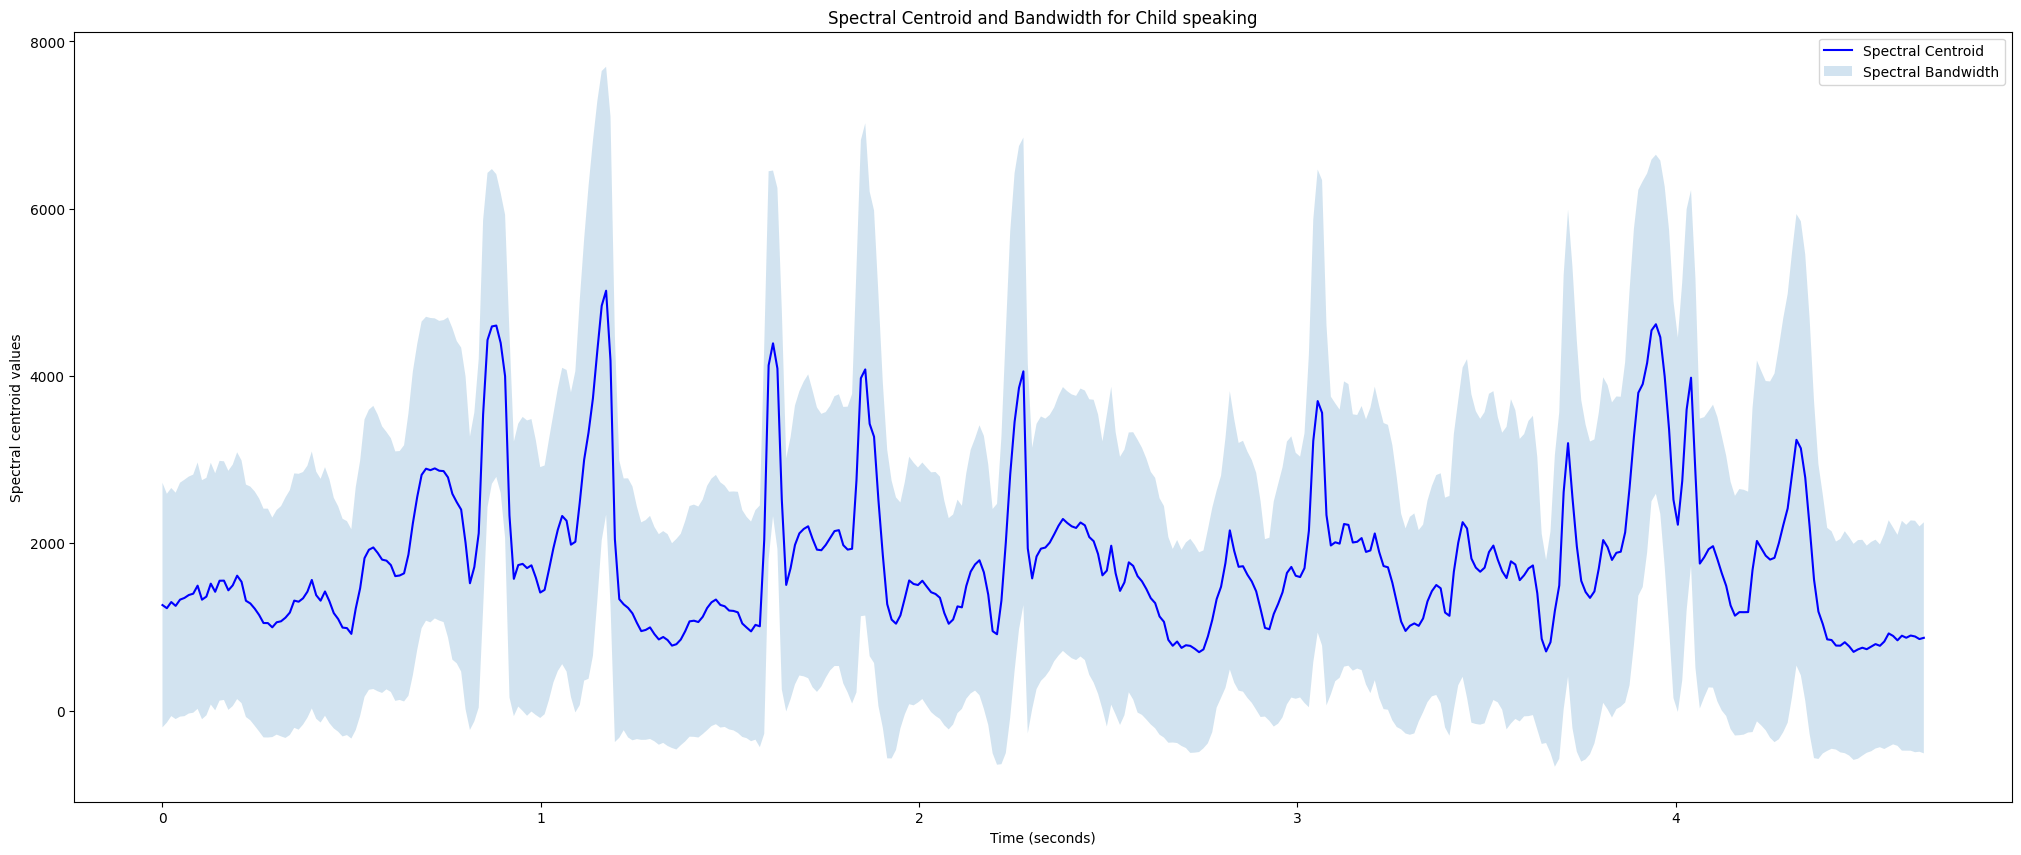

In [27]:
# Calculate spectral centroid
sc1 = librosa.feature.spectral_centroid(y=file1, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
# Calculate spectral bandwidth
sban1 = librosa.feature.spectral_bandwidth(y=file1, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
# Plot spectral centroid and bandwidth
plot_spectral_centroid(sc1, sban1, HOP_LENGTH, 'Spectral Centroid and Bandwidth for Child speaking')

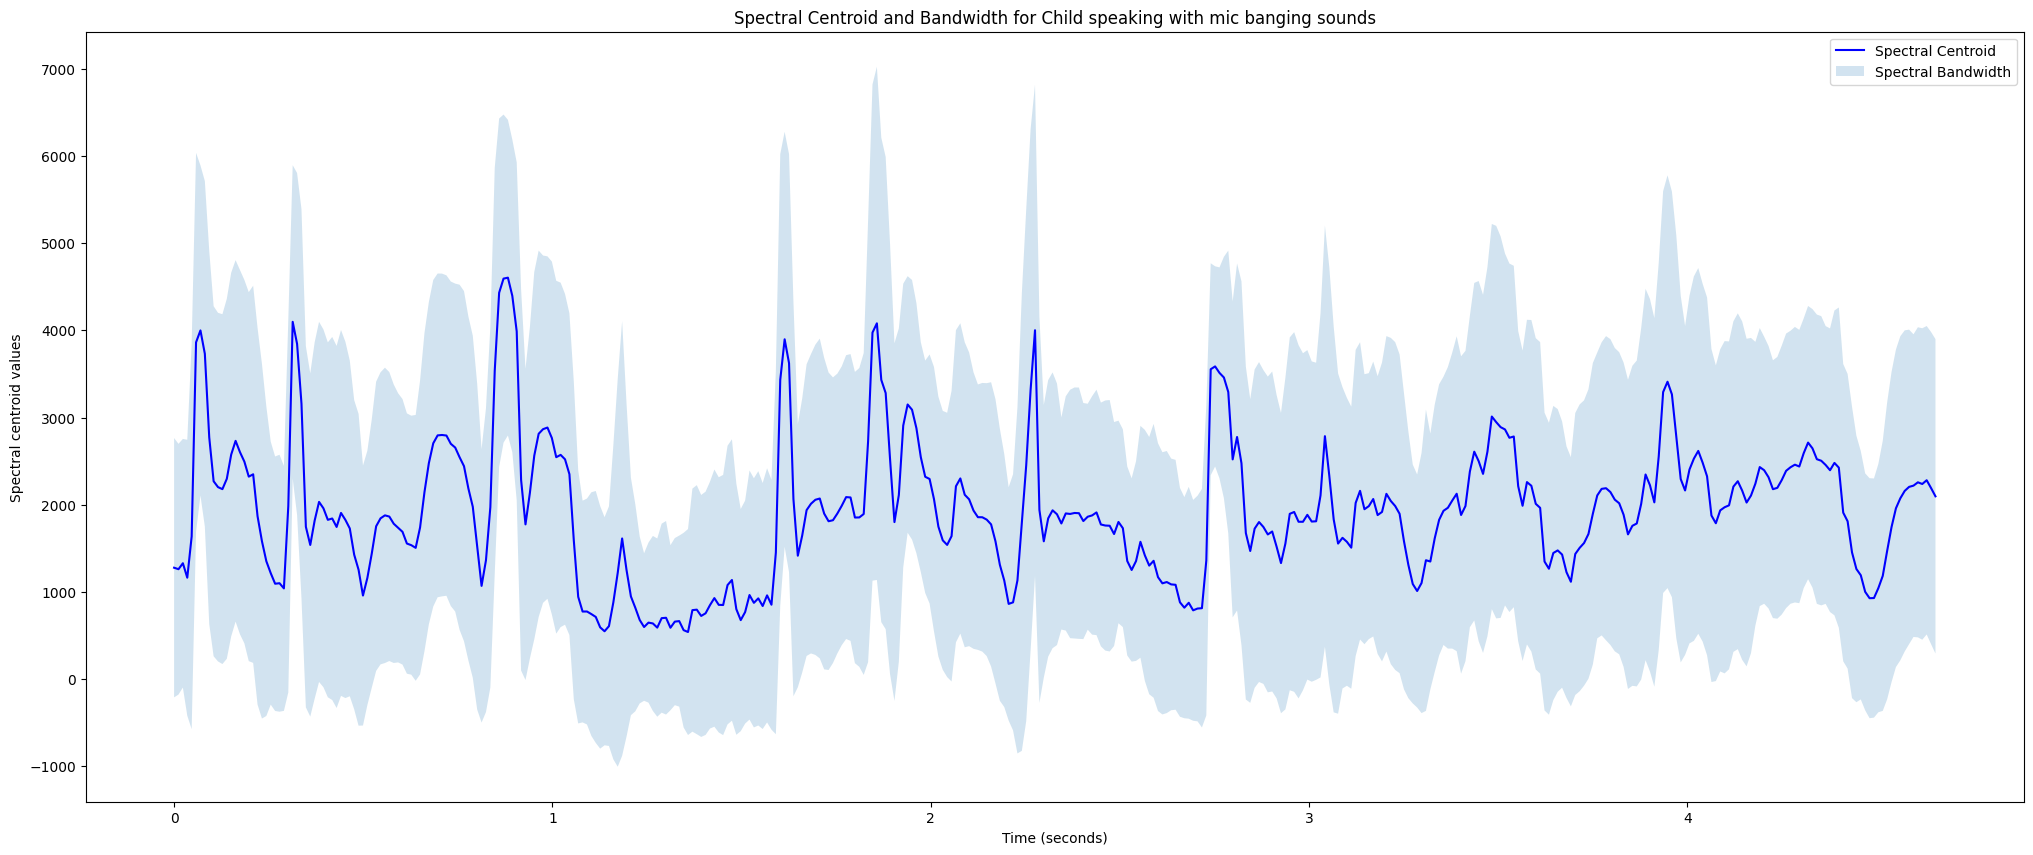

In [28]:
# Calculate spectral centroid
sc2 = librosa.feature.spectral_centroid(y=file2, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
# Calculate spectral bandwidth
sban2 = librosa.feature.spectral_bandwidth(y=file2, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
# Plot spectral centroid and bandwidth
plot_spectral_centroid(sc2, sban2, HOP_LENGTH, 'Spectral Centroid and Bandwidth for Child speaking with mic banging sounds')